In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
nav = pd.read_csv("data/processed/nav_history_cleaned.csv")
transactions = pd.read_csv("data/processed/investor_transactions_cleaned.csv")
performance = pd.read_csv("data/processed/scheme_performance_cleaned.csv")

In [3]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [5]:
nav['date'] = pd.to_datetime(nav['date'])

In [6]:
nav = nav.sort_values(['amfi_code','date'])
nav['daily_return'] = (nav.groupby('amfi_code')['nav'].pct_change())

In [7]:
var_results=[]
for code in nav['amfi_code'].unique():
    returns=nav[nav['amfi_code']==code]['daily_return'].dropna()
    var=np.percentile(returns,5)
    cvar=returns[returns<=var].mean()
    var_results.append([code,var,cvar])

var_report=pd.DataFrame(var_results,columns=['amfi_code','VaR_95','CVaR_95'])
var_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [8]:
var_report.to_csv("var_cvar_report.csv",index=False)

In [9]:
nav['rolling_mean']=nav.groupby('amfi_code')['daily_return'].rolling(90).mean().reset_index(level=0,drop=True)
nav['rolling_std']=nav.groupby('amfi_code')['daily_return'].rolling(90).std().reset_index(level=0,drop=True)

nav['rolling_sharpe']=nav['rolling_mean']/nav['rolling_std']*np.sqrt(252)

In [10]:
funds = nav['amfi_code'].unique()[:5]

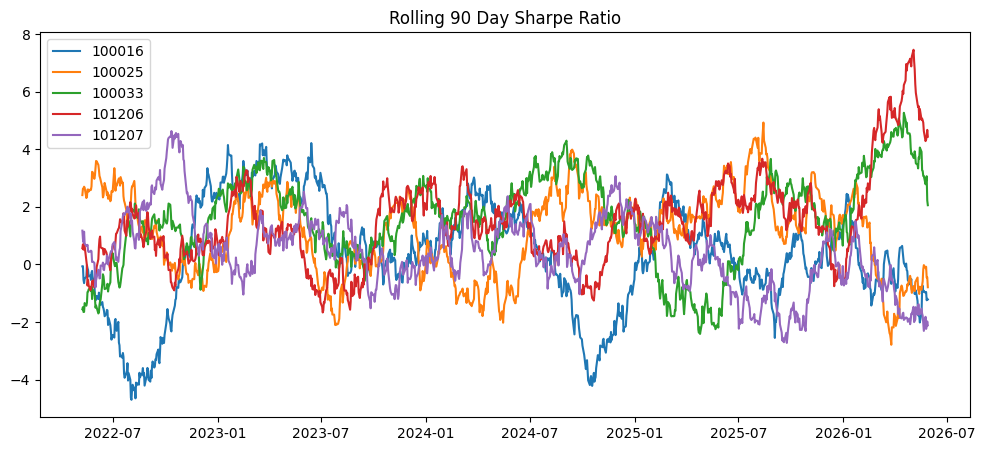

In [11]:
plt.figure(figsize=(12,5))


for f in funds:

    temp = nav[nav['amfi_code']==f]

    plt.plot(temp['date'],temp['rolling_sharpe'],label=f)

plt.legend()
plt.title("Rolling 90 Day Sharpe Ratio")
plt.savefig("rolling_sharpe_chart.png")
plt.show()

In [12]:
print(transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [13]:
transactions.columns = (transactions.columns.str.strip().str.lower())

In [14]:
print(transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [15]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [16]:
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])

In [17]:
transactions['cohort_year'] = (transactions.groupby('investor_id')['transaction_date'].transform('min').dt.year)

In [19]:
cohort = (transactions.groupby('cohort_year').agg(avg_sip_amount=('amount_inr', 'mean'),total_invested=('amount_inr', 'sum')))
print(cohort)

             avg_sip_amount  total_invested
cohort_year                                
2024          107422.541832      3491125187
2025          109158.577061        30455243


In [28]:
transactions.columns = transactions.columns.str.strip().str.lower()
sip = transactions[transactions['transaction_type'] == "SIP"].copy()
sip.columns = sip.columns.str.strip().str.lower()

In [30]:
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])

In [32]:
cohort = (transactions.groupby('cohort_year').agg(avg_sip_amount=('amount_inr', 'mean'),total_invested=('amount_inr', 'sum')))

print(cohort)

             avg_sip_amount  total_invested
cohort_year                                
2024          107422.541832      3491125187
2025          109158.577061        30455243


In [33]:
sip = transactions[transactions['transaction_type'] == "SIP"].copy()

In [34]:
sip['transaction_date'] = pd.to_datetime(sip['transaction_date'])

In [35]:
sip = sip.sort_values(['investor_id', 'transaction_date'])

In [36]:
sip['gap_days'] = (sip.groupby('investor_id')['transaction_date'].diff().dt.days)

In [37]:
import numpy as np
sip['risk_flag'] = np.where(sip['gap_days'] > 35,"At Risk","Healthy")

In [38]:
sip.head(10)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days,risk_flag
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN,Healthy
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,76.0,At Risk
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN,Healthy
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,176.0,At Risk
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,238.0,At Risk
12652,INV000003,2024-07-16,101207,SIP,2676,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,NaN,Healthy
27622,INV000003,2025-03-11,149322,SIP,15185,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,238.0,At Risk
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN,Healthy
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0,Healthy
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0,Healthy


In [39]:
import pandas as pd

In [40]:
df = pd.read_csv("data/processed/scheme_performance_cleaned.csv")

In [41]:
risk = input("Enter Risk Appetite (Low/Moderate/High): ")

Enter Risk Appetite (Low/Moderate/High):  Low


In [42]:
result = df[df['risk_grade'] == risk]

In [43]:
print(result.sort_values('sharpe_ratio', ascending=False).head(3))

    amfi_code                               scheme_name  \
14     120507  ICICI Pru Liquid Fund - Regular - Growth   
23     120844      Kotak Liquid Fund - Regular - Growth   
30     101208       ABSL Liquid Fund - Regular - Growth   

                  fund_house category     plan  return_1yr_pct  \
14       ICICI Prudential MF   Liquid  Regular            8.89   
23         Kotak Mahindra MF   Liquid  Regular            4.26   
30  Aditya Birla Sun Life MF   Liquid  Regular            6.18   

    return_3yr_pct  return_5yr_pct  benchmark_3yr_pct  alpha  beta  \
14            7.68            7.94               5.83   1.85  0.26   
23            6.18            8.26               4.66   1.52  0.47   
30            5.14            7.95               3.96   1.18  0.43   

    sharpe_ratio  sortino_ratio  std_dev_ann_pct  max_drawdown_pct  aum_crore  \
14          7.68          10.37              0.5             -2.62      39116   
23          6.18           9.70              0.5       

In [48]:
print(performance.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')


In [49]:
performance['weight'] = performance['aum_crore']

In [52]:
performance['weight_norm'] = (performance['weight'] /performance.groupby('scheme_name')['weight'].transform('sum'))

In [53]:
performance['weight_sq'] = performance['weight_norm'] ** 2

hhi = performance.groupby('scheme_name')['weight_sq'].sum()

print(hhi.head())

scheme_name
ABSL Frontline Equity Fund - Regular - Growth    1.0
ABSL Liquid Fund - Regular - Growth              1.0
ABSL Small Cap Fund - Regular - Growth           1.0
Axis Bluechip Fund - Direct - Growth             1.0
Axis Bluechip Fund - Regular - Growth            1.0
Name: weight_sq, dtype: float64
